In [1]:
!pip install windrose

Defaulting to user installation because normal site-packages is not writeable


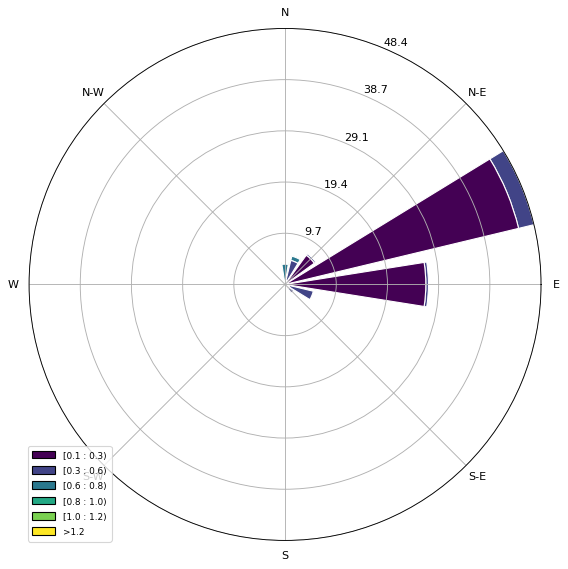

In [27]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt
from windrose import WindroseAxes

# Load the DFSU file
filename = r"D:\Phd Research\Wave Model\Simulation\Climate_Change_condition\Without_reef_scenarios\Wave_Model_Sep_1943_10_yr.sw - Result Files\wave_CC_10_yr.dfsu"
dfsu = mikeio.Dfsu(filename)

# Set the correct item indices for Current speed and Current direction
sigwvht = 0  # Replace with the correct index for 'Current speed'
mwd = 2  # Replace with the correct index for 'Current direction'

# Use the provided element index
element_index = 119379

# Read the data for speed and direction
dataset = dfsu.read(items=[sigwvht, mwd])

# Extract speed and direction data for the selected element
sigwvht = dataset[0].to_numpy()[:, element_index]  # Extract significant wave heiht for this element
mwd = dataset[1].to_numpy()[:, element_index]  # Extract direction for this element

# Convert direction to the range 0-360 degrees (if necessary)
direction_data = np.mod(mwd, 360)

# Plot the rose diagram for the current data
ax = WindroseAxes.from_ax()
ax.bar(mwd, sigwvht, normed=True, opening=0.8, edgecolor='white')
ax.set_legend()

plt.show()


In [3]:


# List the available items in the DFSU file
for item in dfsu.items:
    print(item.name)


Sign. Wave Height
Wave Period, T02
Mean Wave Direction
x-comp. of wave height vector
y-comp. of wave height vector
Rad. Stress, Sxx
Rad. Stress, Sxy
Rad. Stress, Syy
Wave power, p
Wave power, Px
Wave power, Py


In [4]:
# Print item names with their index
for idx, item in enumerate(dfsu.items):
    print(f"Index {idx}: {item.name}")


Index 0: Sign. Wave Height
Index 1: Wave Period, T02
Index 2: Mean Wave Direction
Index 3: x-comp. of wave height vector
Index 4: y-comp. of wave height vector
Index 5: Rad. Stress, Sxx
Index 6: Rad. Stress, Sxy
Index 7: Rad. Stress, Syy
Index 8: Wave power, p
Index 9: Wave power, Px
Index 10: Wave power, Py


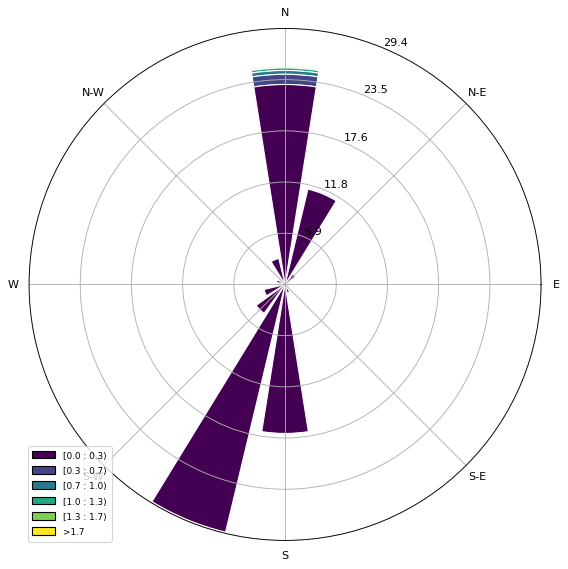

In [13]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt
from windrose import WindroseAxes

# Load the DFSU file
filename = r"D:\Phd Research\Prototype HD Model\Simulation\Without Reef Scenarios\Climate change condition\10-yr return period storm CC.m21fm - Result Files\10-yr_CC.dfsu"
dfsu = mikeio.Dfsu(filename)

# Set the correct item indices for Current Speed and Current Direction
current_speed_index = 5  # Replace with the correct index for 'Current speed'
current_dir_index = 6    # Replace with the correct index for 'Current direction'

# Use the provided element index
element_index = 125589

# Read the data for current speed and direction
dataset = dfsu.read(items=[current_speed_index, current_dir_index])

# Extract current speed and direction data for the selected element
current_speed = dataset[0].to_numpy()[:, element_index]  # Extract current speed for this element
current_dir_radian = dataset[1].to_numpy()[:, element_index]  # Extract current direction (in radians) for this element

# Convert direction from radians to degrees
current_dir_degrees = np.degrees(current_dir_radian)

# Ensure direction is in the range 0-360 degrees
current_dir_degrees = np.mod(current_dir_degrees, 360)

# Plot the current rose diagram
ax = WindroseAxes.from_ax()
ax.bar(current_dir_degrees, current_speed, normed=True, opening=0.8, edgecolor='white')
ax.set_legend()

# Show the plot
plt.show()


In [8]:
# Print item names with their index
for idx, item in enumerate(dfsu.items):
    print(f"Index {idx}: {item.name}")

Index 0: Surface elevation
Index 1: Still water depth
Index 2: Total water depth
Index 3: U velocity
Index 4: V velocity
Index 5: Current speed
Index 6: Current direction
Index 7: Wind U velocity
Index 8: Wind V velocity
Index 9: Manning number
Index 10: Drag coefficient
Index 11: Bed shearstress
Index 12: Bed shearstress - x-component
Index 13: Bed shearstress - y-component
Index 14: CFL number (HD)


In [2]:
!pip install windrose


Defaulting to user installation because normal site-packages is not writeable


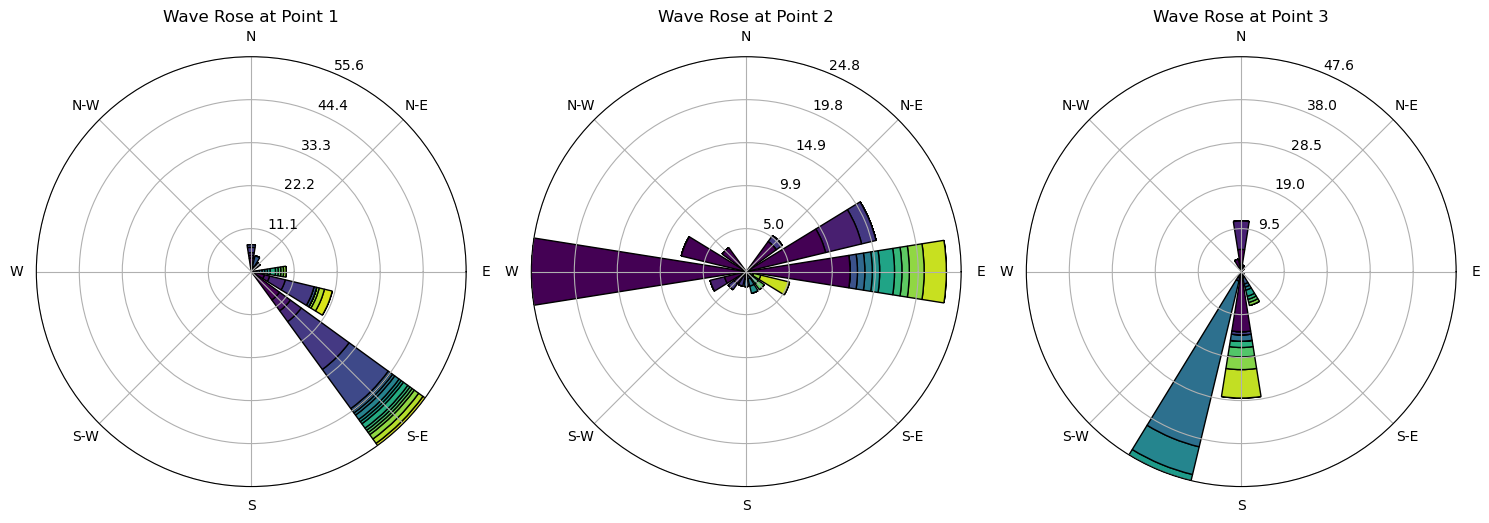

In [6]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt
from windrose import WindroseAxes

# Define the file path
dfsu_file = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey_with_reef_barrier_reef_Pattern.sw - Result Files\small_scale_wave_result_with_barrier_reef.dfsu"

# Define target coordinates (X, Y)
target_coords = {
    "Point 1": (730846, 3174694),
    "Point 2": (732237, 3178505),
    "Point 3": (736214, 3176975)
}

# Load the DFSU file
ds = mikeio.Dfsu(dfsu_file)

# Extract element coordinates
mesh_x, mesh_y = ds.geometry.element_coordinates[:, 0], ds.geometry.element_coordinates[:, 1]

# Function to find the nearest element index
def find_nearest_element(x, y, mesh_x, mesh_y):
    distances = np.sqrt((mesh_x - x) ** 2 + (mesh_y - y) ** 2)
    return np.argmin(distances)

# Get element indices for target locations
element_indices = {name: find_nearest_element(x, y, mesh_x, mesh_y) for name, (x, y) in target_coords.items()}

# Read Mean Wave Direction and Significant Wave Height
wave_dir_data = ds.read(items=["Mean Wave Direction"])
wave_hs_data = ds.read(items=["Sign. Wave Height"])

# Create wind roses for each point
fig, axes = plt.subplots(1, 3, figsize=(15, 5), subplot_kw={'projection': 'windrose'})

for ax, (name, idx) in zip(axes, element_indices.items()):
    wave_dir = wave_dir_data[0].to_numpy()[:, idx]  # Extract wave direction for this point
    wave_hs = wave_hs_data[0].to_numpy()[:, idx]  # Extract wave height for this point
    
    # Remove NaN values (if any)
    valid_mask = ~np.isnan(wave_dir) & ~np.isnan(wave_hs)
    wave_dir = wave_dir[valid_mask]
    wave_hs = wave_hs[valid_mask]

    # Ensure valid bins
    if len(wave_hs) > 0 and np.max(wave_hs) > 0:
        bins = np.arange(0, np.max(wave_hs) + 0.1, 0.1)
    else:
        bins = [0.1]  # Default bin to prevent errors

    # Plot wind rose
    ax.bar(wave_dir, wave_hs, normed=True, bins=bins, opening=0.8, edgecolor='black')
    ax.set_title(f"Wave Rose at {name}")

plt.tight_layout()
plt.show()



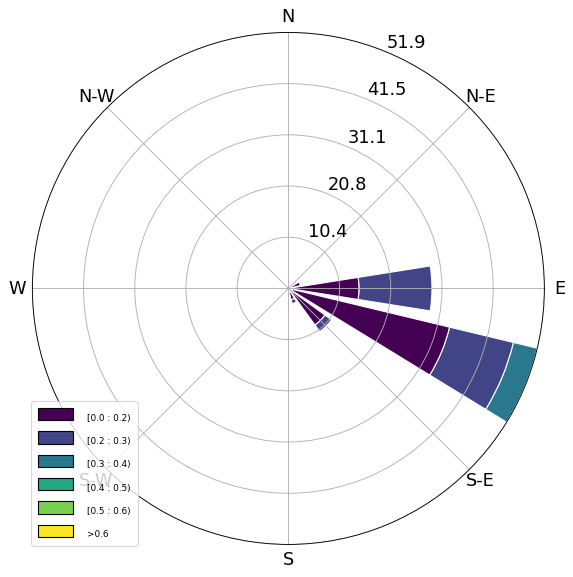

In [20]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt
from windrose import WindroseAxes

# Load the DFSU file
filename = r"D:\Phd Research\Wave Model\Simulation\Climate_Change_condition\Without_reef_scenarios\Wave_Model_Sep_1943_10_yr.sw - Result Files\wave_CC_10_yr.dfsu"
dfsu = mikeio.Dfsu(filename)

# Set the correct item indices for Current speed and Current direction
sigwvht = 0  # Replace with the correct index for 'Current speed'
mwd = 2  # Replace with the correct index for 'Current direction'

# Use the provided element index
element_index = 125589

# Read the data for speed and direction
dataset = dfsu.read(items=[sigwvht, mwd])

# Extract speed and direction data for the selected element
sigwvht = dataset[0].to_numpy()[:, element_index]  # Extract significant wave height for this element
mwd = dataset[1].to_numpy()[:, element_index]  # Extract direction for this element

# Convert direction to the range 0-360 degrees (if necessary)
direction_data = np.mod(mwd, 360)

# Plot the rose diagram for the current data
ax = WindroseAxes.from_ax()

# Increase the plot and legend text size
ax.bar(mwd, sigwvht, normed=True, opening=0.8, edgecolor='white')

# Set font sizes
ax.set_legend(fontsize=16, prop={'size':16})  # Increase the color legend text size and the legend labels
ax.tick_params(labelsize=16)  # Increase the axis tick label size

# Set labels for the plot
# ax.set_title("Wave Rose", fontsize=16)  # Set title with larger text
# ax.set_xlabel("Wave Direction", fontsize=14)  # Set x-label
# ax.set_ylabel("Significant Wave Height", fontsize=14)  # Set y-label

plt.show()


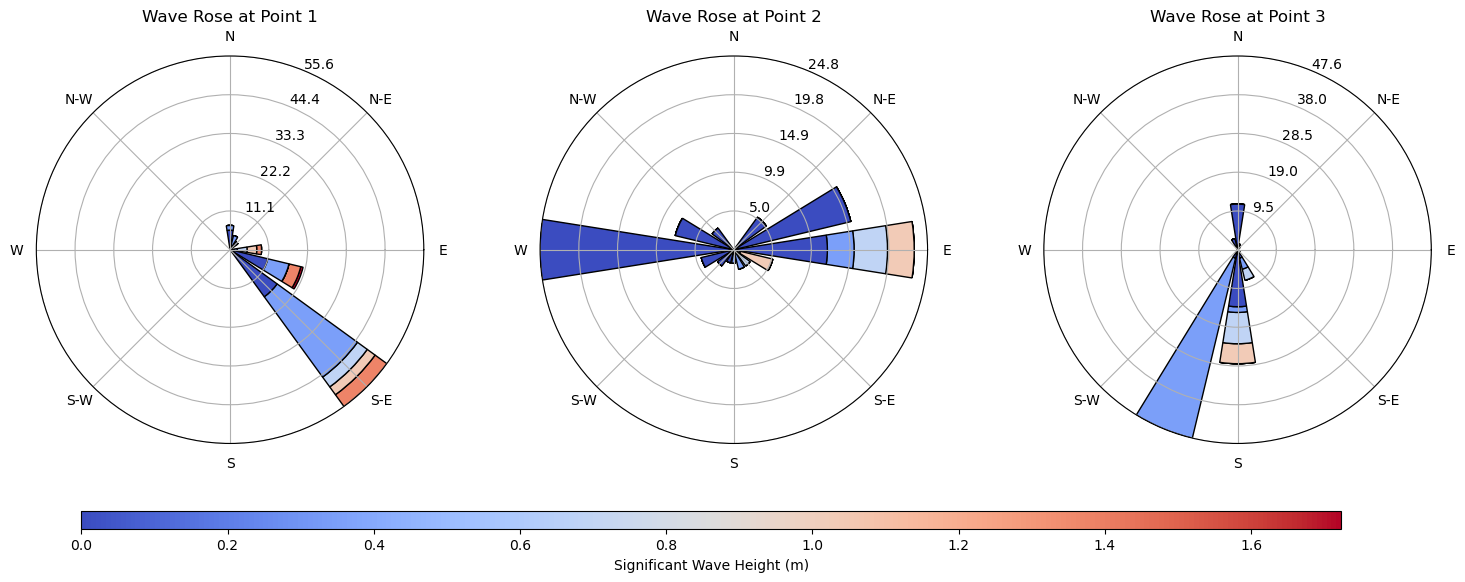

In [12]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from windrose import WindroseAxes

# Define the file path
dfsu_file = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey_with_reef_barrier_reef_Pattern.sw - Result Files\small_scale_wave_result_with_barrier_reef.dfsu"

# Define target coordinates (X, Y)
target_coords = {
    "West side": (730846, 3174694),
    "North side": (732237, 3178505),
    "East side": (736214, 3176975)
}

# Load the DFSU file
ds = mikeio.Dfsu(dfsu_file)

# Extract element coordinates
mesh_x, mesh_y = ds.geometry.element_coordinates[:, 0], ds.geometry.element_coordinates[:, 1]

# Function to find the nearest element index
def find_nearest_element(x, y, mesh_x, mesh_y):
    distances = np.sqrt((mesh_x - x) ** 2 + (mesh_y - y) ** 2)
    return np.argmin(distances)

# Get element indices for target locations
element_indices = {name: find_nearest_element(x, y, mesh_x, mesh_y) for name, (x, y) in target_coords.items()}

# Read Mean Wave Direction and Significant Wave Height
wave_dir_data = ds.read(items=["Mean Wave Direction"])
wave_hs_data = ds.read(items=["Sign. Wave Height"])

# Get global max wave height for consistent color scale
all_wave_heights = np.concatenate([wave_hs_data[0].to_numpy()[:, idx] for idx in element_indices.values()])
global_max_hs = np.nanmax(all_wave_heights) if np.any(~np.isnan(all_wave_heights)) else 1.0  # Avoid NaN issues

# Define colormap and normalization
cmap = cm.coolwarm
norm = mcolors.Normalize(vmin=0, vmax=global_max_hs)

# Create wind roses for each point
fig, axes = plt.subplots(1, 3, figsize=(18, 6), subplot_kw={'projection': 'windrose'})

for ax, (name, idx) in zip(axes, element_indices.items()):
    wave_dir = wave_dir_data[0].to_numpy()[:, idx]  # Extract wave direction for this point
    wave_hs = wave_hs_data[0].to_numpy()[:, idx]  # Extract wave height for this point

    # Remove NaN values (if any)
    valid_mask = ~np.isnan(wave_dir) & ~np.isnan(wave_hs)
    wave_dir = wave_dir[valid_mask]
    wave_hs = wave_hs[valid_mask]

    # Ensure valid bins
    bins = np.linspace(0, global_max_hs, 6) if global_max_hs > 0 else [0.1]

    # Plot wind rose with consistent colormap
    ax.bar(wave_dir, wave_hs, normed=True, bins=bins, opening=0.8, edgecolor='black', cmap=cmap)
    ax.set_title(f"Wave Rose at {name}")

# Add a single color bar below all plots
cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.03])  # [left, bottom, width, height]
sm = cm.ScalarMappable(norm=norm, cmap=cmap)  # Create a mappable object for the color bar
sm.set_array([])  # Dummy array for color bar
cbar = plt.colorbar(sm, cax=cbar_ax, orientation="horizontal")
cbar.set_label("Significant Wave Height (m)")

# Adjust subplot spacing manually instead of tight_layout
plt.subplots_adjust(bottom=0.15, wspace=0.3)  # Adjust bottom margin and width spacing

plt.show()



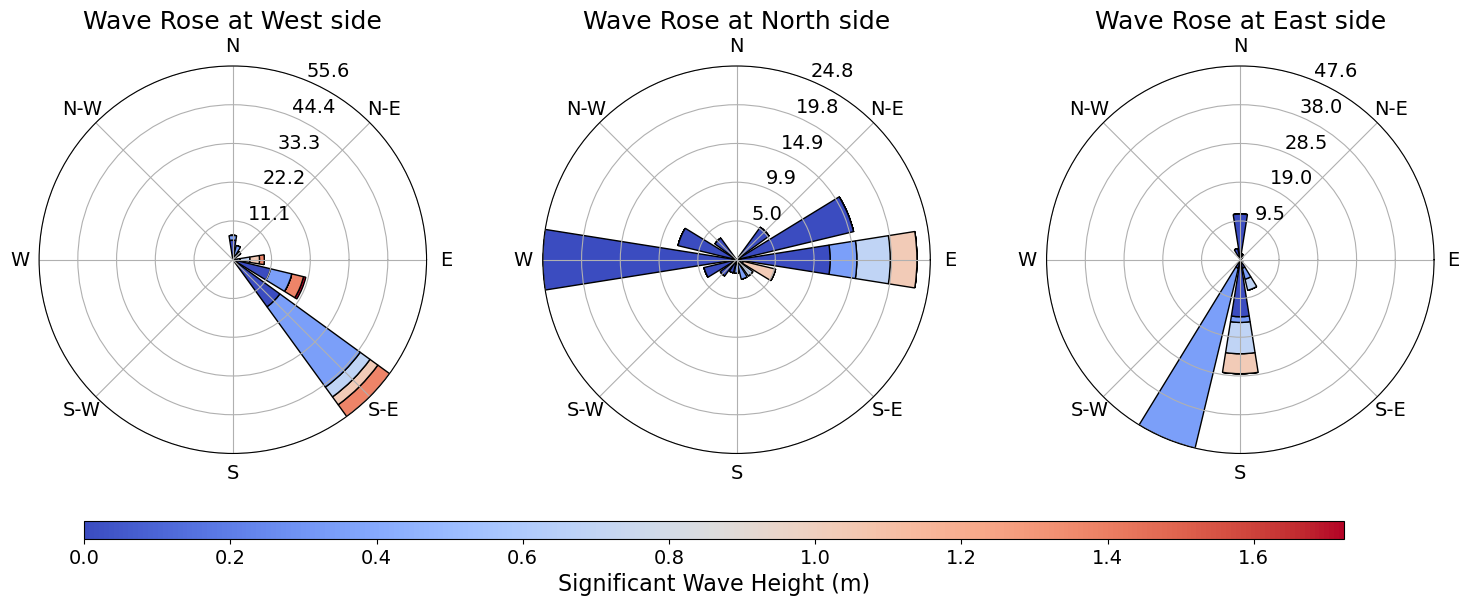

In [1]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from windrose import WindroseAxes

# ——— Increase global font size ———
plt.rcParams.update({
    'font.size': 14,           # base font size for text
    'axes.titlesize': 16,      # axes title
    'axes.labelsize': 14,      # x/y labels
    'xtick.labelsize': 12,     # tick labels
    'ytick.labelsize': 12,
    'legend.fontsize': 12,     # legend text
    'figure.titlesize': 18     # figure suptitle if used
})

# Define the file path
dfsu_file = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey_with_reef_barrier_reef_Pattern.sw - Result Files\small_scale_wave_result_with_barrier_reef.dfsu"

# Define target coordinates (X, Y)
target_coords = {
    "West side": (730846, 3174694),
    "North side": (732237, 3178505),
    "East side": (736214, 3176975)
}

# Load the DFSU file
ds = mikeio.Dfsu(dfsu_file)

# Extract element coordinates
mesh_x, mesh_y = ds.geometry.element_coordinates[:, 0], ds.geometry.element_coordinates[:, 1]

# Function to find the nearest element index
def find_nearest_element(x, y, mesh_x, mesh_y):
    distances = np.hypot(mesh_x - x, mesh_y - y)
    return np.argmin(distances)

# Get element indices for target locations
element_indices = {
    name: find_nearest_element(x, y, mesh_x, mesh_y)
    for name, (x, y) in target_coords.items()
}

# Read Mean Wave Direction and Significant Wave Height
wave_dir_data = ds.read(items=["Mean Wave Direction"])
wave_hs_data  = ds.read(items=["Sign. Wave Height"])

# Get global max wave height for consistent color scale
all_wave_heights = np.concatenate([
    wave_hs_data[0].to_numpy()[:, idx]
    for idx in element_indices.values()
])
global_max_hs = np.nanmax(all_wave_heights) if np.any(~np.isnan(all_wave_heights)) else 1.0

# Define colormap and normalization
cmap = cm.coolwarm
norm = mcolors.Normalize(vmin=0, vmax=global_max_hs)

# Create wind roses for each point
fig, axes = plt.subplots(1, 3, figsize=(18, 6), subplot_kw={'projection': 'windrose'})

for ax, (name, idx) in zip(axes, element_indices.items()):
    wave_dir = wave_dir_data[0].to_numpy()[:, idx]
    wave_hs  = wave_hs_data[0].to_numpy()[:, idx]

    # Remove NaNs
    mask = ~np.isnan(wave_dir) & ~np.isnan(wave_hs)
    wave_dir = wave_dir[mask]
    wave_hs   = wave_hs[mask]

    # Define bins for wave heights
    bins = np.linspace(0, global_max_hs, 6)

    # Plot: note 'normed' is deprecated in newer windrose, but kept for compatibility
    ax.bar(
        wave_dir,
        wave_hs,
        normed=True,
        bins=bins,
        opening=0.8,
        edgecolor='black',
        cmap=cmap
    )

    # Title with explicit fontsize (overrides rcParams if needed)
    ax.set_title(f"Wave Rose at {name}", fontsize=18)
    # Increase tick labels
    ax.tick_params(axis='both', which='major', labelsize=14)

# Add a single color bar below all plots
cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.03])
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = plt.colorbar(sm, cax=cbar_ax, orientation="horizontal")
cbar.set_label("Significant Wave Height (m)", fontsize=16)
cbar.ax.tick_params(labelsize=14)

# Adjust layout
plt.subplots_adjust(bottom=0.15, wspace=0.3)

plt.show()
